<a href="https://colab.research.google.com/github/kritikkaaa/Netflix_Recommendation_SVD/blob/main/Netflix_SVD_Recommendation_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install Dependencies


In [1]:
!pip uninstall -y numpy
!pip install numpy==1.26.4
!pip install scikit-surprise

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 

#  Imports


In [2]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate, train_test_split
from surprise import accuracy


#Mount Google Drive

In [3]:
drive.mount('/content/drive')

#Load Raw Dataset
netflix_dataset = pd.read_csv(
    '/content/drive/MyDrive/netflix_dataset/combined_data_1.txt',
    header=None,
    names=['Cust_Id', 'Rating'],
    usecols=[0, 1]
)

print("Raw Dataset Shape:", netflix_dataset.shape)
print(netflix_dataset.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw Dataset Shape: (24058263, 2)
   Cust_Id  Rating
0       1:     NaN
1  1488844     3.0
2   822109     5.0
3   885013     4.0
4    30878     4.0


# Exploratory Data Analysis

In [4]:
print("Data Types:", netflix_dataset.dtypes)
print("Missing Values:", netflix_dataset.isnull().sum())

Data Types: Cust_Id     object
Rating     float64
dtype: object
Missing Values: Cust_Id       0
Rating     4499
dtype: int64


In [5]:
# Count movies (rows where Rating is NaN contain movie IDs)
movie_count = netflix_dataset['Rating'].isnull().sum()
print(f"Total Movies: {movie_count}")

Total Movies: 4499


In [6]:
# Count unique customers (excluding movie ID rows)
customer_count = netflix_dataset['Cust_Id'].nunique() - movie_count
print(f"Total Unique Customers: {customer_count}")


Total Unique Customers: 470758


In [7]:
# Total number of ratings
total_ratings = netflix_dataset['Cust_Id'].count() - movie_count
print(f"Total Ratings: {total_ratings}")

Total Ratings: 24053764


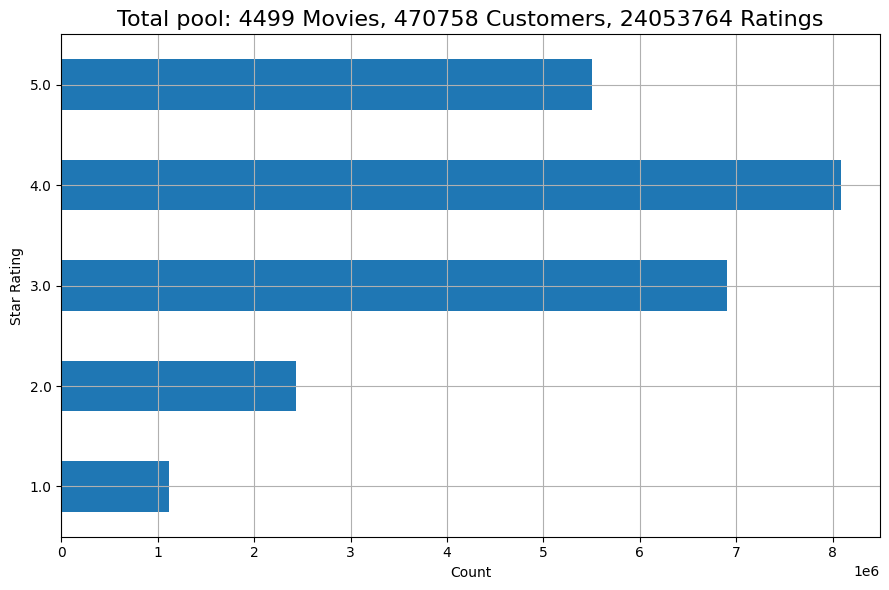

In [8]:
# Star rating distribution
stars = netflix_dataset.groupby('Rating')['Rating'].agg(['count'])
ax = stars.plot(kind='barh', legend=False, figsize=(9, 6))
plt.title(
    f'Total pool: {movie_count} Movies, {customer_count} Customers, {total_ratings} Ratings',
    fontsize=16
)
plt.xlabel("Count")
plt.ylabel("Star Rating")
plt.grid(True)
plt.tight_layout()
plt.show()

#Feature Engineering: Extract Movie IDs

In [9]:
netflix_dataset['Movie_id'] = netflix_dataset['Cust_Id'].apply(
    lambda x: x[:-1] if isinstance(x, str) and ':' in x else None
)
netflix_dataset['Movie_id'] = netflix_dataset['Movie_id'].ffill()

In [10]:
# Drop rows where Rating is NaN (those were movie ID rows)
netflix_dataset.dropna(inplace=True)

In [11]:
# Fix data types
netflix_dataset["Cust_Id"] = netflix_dataset["Cust_Id"].astype(int)
netflix_dataset["Movie_id"] = netflix_dataset["Movie_id"].astype(int)

print("\nCleaned Dataset Shape:", netflix_dataset.shape)
print(netflix_dataset.head())
print(netflix_dataset.tail())



Cleaned Dataset Shape: (24053764, 3)
   Cust_Id  Rating  Movie_id
1  1488844     3.0         1
2   822109     5.0         1
3   885013     4.0         1
4    30878     4.0         1
5   823519     3.0         1
          Cust_Id  Rating  Movie_id
24058258  2591364     2.0      4499
24058259  1791000     2.0      4499
24058260   512536     5.0      4499
24058261   988963     3.0      4499
24058262  1704416     3.0      4499


#Filter Sparse Movies & Users (Benchmarking)

In [12]:
# Movies with fewer than 60th percentile ratings are dropped
dataset_movie_summary = netflix_dataset.groupby('Movie_id')['Rating'].agg(['count'])
movie_benchmark = round(dataset_movie_summary['count'].quantile(0.6), 0)
drop_movie_list = dataset_movie_summary[dataset_movie_summary['count'] < movie_benchmark].index
print(f"Movie Benchmark: {movie_benchmark} | Movies to drop: {len(drop_movie_list)}")

Movie Benchmark: 908.0 | Movies to drop: 2699


In [13]:
# Customers with fewer than 60th percentile ratings are dropped
dataset_cust_summary = netflix_dataset.groupby('Cust_Id')['Rating'].agg(['count'])
cust_benchmark = round(dataset_cust_summary['count'].quantile(0.6), 0)
cust_to_drop = dataset_cust_summary[dataset_cust_summary['count'] < cust_benchmark].index
print(f"Customer Benchmark: {cust_benchmark} | Customers to drop: {len(cust_to_drop)}")

Customer Benchmark: 36.0 | Customers to drop: 282042


In [14]:
# Apply filters
netflix_dataset = netflix_dataset[~netflix_dataset['Movie_id'].isin(drop_movie_list)]
netflix_dataset = netflix_dataset[~netflix_dataset['Cust_Id'].isin(cust_to_drop)]
print(f"After trimming, dataset shape: {netflix_dataset.shape}")

After trimming, dataset shape: (19695836, 3)


#Load Movie Titles

In [15]:
df_title = pd.read_csv(
    '/content/drive/MyDrive/netflix_dataset/movie_titles.csv',
    encoding='latin',
    header=None,
    usecols=[0, 1, 2],
    names=['Movie_id', 'Year', 'Movie_Title']
)
print("\nMovie Titles Sample:\n", df_title.head())


Movie Titles Sample:
    Movie_id    Year                   Movie_Title
0         1  2003.0               Dinosaur Planet
1         2  2004.0    Isle of Man TT 2004 Review
2         3  1997.0                     Character
3         4  1994.0  Paula Abdul's Get Up & Dance
4         5  2004.0      The Rise and Fall of ECW


In [16]:
#Prepare Data for Surprise Library
reader = Reader()

# FIX: Use full filtered dataset instead of just 100k rows
data = Dataset.load_from_df(
    netflix_dataset[['Cust_Id', 'Movie_id', 'Rating']],
    reader
)

#Train / Test Split

In [17]:
# Proper holdout evaluation instead of only cross-validation
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

In [18]:
#Train SVD Model
model = SVD(random_state=42)
model.fit(trainset)
print("Model trained successfully.")

Model trained successfully.


In [19]:
# Evaluate on holdout test set
predictions = model.test(testset)
print(f"Test Set RMSE: {accuracy.rmse(predictions):.4f}")
print(f"Test Set MAE : {accuracy.mae(predictions):.4f}")

RMSE: 0.8584
Test Set RMSE: 0.8584
MAE:  0.6654
Test Set MAE : 0.6654


In [20]:
# Additional cross-validation for robust performance estimate
print("Running 3-fold Cross Validation...")

# Used a sample of 100k rows to avoid RAM crash
data_sample = Dataset.load_from_df(
    netflix_dataset[['Cust_Id', 'Movie_id', 'Rating']].sample(100000, random_state=42),
    reader
)

cv_results = cross_validate(model, data_sample, measures=['RMSE', 'MAE'], cv=3, verbose=True)

Running 3-fold Cross Validation...
Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    1.0060  1.0075  1.0017  1.0051  0.0025  
MAE (testset)     0.8082  0.8101  0.8068  0.8084  0.0013  
Fit time          1.34    1.39    1.43    1.39    0.04    
Test time         0.18    0.16    0.16    0.17    0.01    


#Save Trained Model

In [21]:
MODEL_PATH = '/content/drive/MyDrive/netflix_dataset/svd_model.pkl'
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model, f)
print(f"Model saved to: {MODEL_PATH}")

Model saved to: /content/drive/MyDrive/netflix_dataset/svd_model.pkl


In [30]:
#Generate Recommendations for a User
#Made user ID a variable + filter out already-rated movies (not just sparse ones)
USER_ID = 1488844    # Change this to recommend for any user

In [31]:
user_ratings = netflix_dataset[netflix_dataset['Cust_Id'] == USER_ID]
movies_rated_by_user = user_ratings['Movie_id'].nunique()
print(f"User {USER_ID} has rated {movies_rated_by_user} unique movies.")

User 1488844 has rated 513 unique movies.


In [32]:
# Exclude movies already rated by the user (not drop_movie_list)
already_rated = set(user_ratings['Movie_id'].tolist())

# Filter title list to only movies NOT yet rated by user
candidate_movies = df_title[~df_title['Movie_id'].isin(already_rated)].copy()

In [33]:
# Predict scores for all candidate movies
candidate_movies['Estimate_Score'] = candidate_movies['Movie_id'].apply(
    lambda x: model.predict(USER_ID, x).est
)

In [34]:
# Sort by predicted score
candidate_movies_sorted = candidate_movies.sort_values('Estimate_Score', ascending=False)

In [35]:
# Top 10 recommendations
top10 = candidate_movies_sorted.head(10)
print(f"Top 10 Movie Recommendations for User {USER_ID}:")
print(top10[['Movie_id', 'Year', 'Movie_Title', 'Estimate_Score']].to_string(index=False))

Top 10 Movie Recommendations for User 1488844:
 Movie_id   Year                              Movie_Title  Estimate_Score
     2102 1994.0                   The Simpsons: Season 6        4.465755
     2162 2000.0                            CSI: Season 1        4.455850
     3444 2004.0    Family Guy: Freakin' Sweet Collection        4.360935
      621 1997.0                               Armageddon        4.345211
     2290 1992.0                Aladdin: Platinum Edition        4.326327
     2803 1995.0                      Pride and Prejudice        4.314819
      752 1993.0 Star Trek: The Next Generation: Season 7        4.290755
      253 1935.0                     A Night at the Opera        4.258991
     3999 2001.0                  Queer as Folk: Season 1        4.254171
     3523 1992.0 Star Trek: The Next Generation: Season 6        4.253547


# Visualise Top 10 Recommendations

/tmp/ipykernel_51872/643625445.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


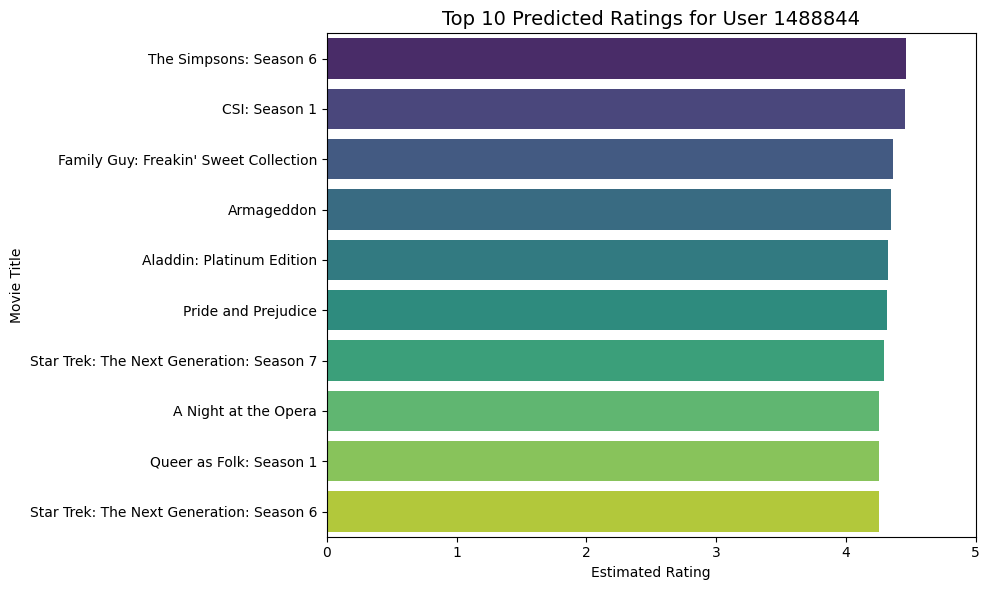

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10,
    x='Estimate_Score',
    y='Movie_Title',
    palette='viridis'
)
plt.title(f'Top 10 Predicted Ratings for User {USER_ID}', fontsize=14)
plt.xlabel('Estimated Rating')
plt.ylabel('Movie Title')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()